In [96]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [97]:
y_reg = df["MedHouseVal"]

y_class = (df["MedHouseVal"] > 2.0).astype(int)

X = df.drop(columns=["MedHouseVal"])

In [98]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

In [100]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,r2_score

knn_reg = KNeighborsRegressor(n_neighbors=25)
knn_reg.fit(X_train_r, y_train_r)

y_pred_r = knn_reg.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
print("Regression MSE:", mse)
print(r2_score(y_test_r,y_pred_r))

Regression MSE: 0.42652791265056134
0.6745077912827377


In [101]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_clf = KNeighborsClassifier(n_neighbors=25)
knn_clf.fit(X_train_c, y_train_c)

y_pred_c = knn_clf.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
print("Classification Accuracy:", accuracy)
print( classification_report(y_test_c,y_pred_c))
print( confusion_matrix(y_test_c,y_pred_c))

Classification Accuracy: 0.8396317829457365
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      2421
           1       0.83      0.77      0.80      1707

    accuracy                           0.84      4128
   macro avg       0.84      0.83      0.83      4128
weighted avg       0.84      0.84      0.84      4128

[[2144  277]
 [ 385 1322]]


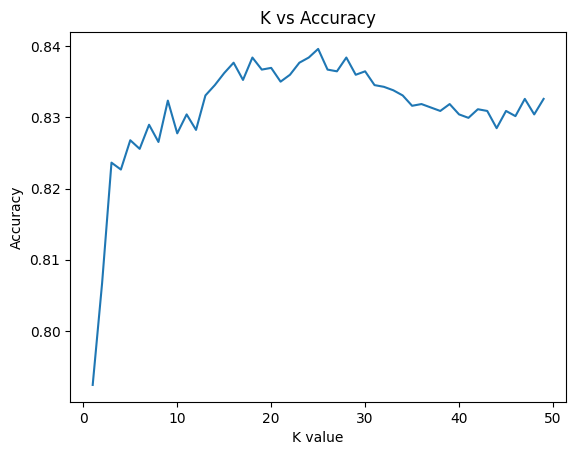

In [102]:
import matplotlib.pyplot as plt

k_values = range(1, 50)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    accuracies.append(accuracy_score(y_test_c, pred))

plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [103]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 25
Best Accuracy: 0.8396317829457365


In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 50)
r2 = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    r2.append(r2_score(y_test_c, pred))

plt.plot(k_values, r2)
plt.xlabel("K value")
plt.ylabel("r2")
plt.title("K vs r2")
plt.show()

In [ ]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)